# 📊 Notebook 01 — Exploratory Data Analysis (EDA)

**Project:** Churn Platform  
**Dataset:** Telco Customer Churn (IBM Sample)  
**Goal:** Understand the data distribution, detect anomalies, and surface patterns that drive churn.

---
### Sections
1. Environment Setup
2. Data Loading & Sanity Check
3. Target Variable Analysis
4. Univariate Analysis — Numerical Features
5. Univariate Analysis — Categorical Features
6. Bivariate Analysis — Features vs Churn
7. Correlation & Multicollinearity
8. Key Findings & EDA Summary

## 1. Environment Setup

In [1]:
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats

# ── Plot aesthetics ──────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.figsize': (12, 5),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})
CHURN_PALETTE = {0: '#2196F3', 1: '#F44336'}   # blue = stayed, red = churned
CHURN_LABELS  = {0: 'No Churn', 1: 'Churn'}

print(f'pandas {pd.__version__} | numpy {np.__version__}')

pandas 2.3.3 | numpy 2.4.2


## 2. Data Loading & Sanity Check

In [2]:
# loading data
df = pd.read_csv('../data/raw_data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [3]:
pd.set_option('display.max_columns',22)

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### A. fixing Columns Data Types

In [6]:
# columns that must change dtypes are
'''
 - gender        obj --> bool
 - partner       obj --> bool
 - dependent     obj --> bool
 - PhoneService  obj --> bool
 - MultipleLines obj --> bool
 - OnlineSecurity , OnlineBackup , DeviceProtection , TechSupport , StreamingTV , StreamingMovies ,  PaperlessBilling , Churn | obj --> bool
 
 - total charge obj --> int 
'''

'\n - gender        obj --> bool\n - partner       obj --> bool\n - dependent     obj --> bool\n - PhoneService  obj --> bool\n - MultipleLines obj --> bool\n - OnlineSecurity , OnlineBackup , DeviceProtection , TechSupport , StreamingTV , StreamingMovies ,  PaperlessBilling , Churn | obj --> bool\n\n - total charge obj --> int \n'

In [7]:
# fixing obj columns 
bool_columns = [
                'Partner',
                'Dependents',
                'PhoneService',
                'MultipleLines',
                'OnlineSecurity' ,
                'OnlineBackup' ,
                'DeviceProtection' ,
                'TechSupport' ,
                'StreamingTV' , 'StreamingMovies' ,  'PaperlessBilling' , 'Churn']

for i in bool_columns:
    df[i] = df[i].apply(lambda x: 1 if x == 'Yes' else 0)

In [8]:
# fixing gender 
df['gender'] = df['gender'].apply(lambda x: 1 if x == 'Male' else 0)

In [9]:
# fixing total charges 
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [10]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,0,0,1,0,1,0,0,DSL,0,1,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,5575-GNVDE,1,0,0,0,34,1,0,DSL,1,0,1,0,0,0,One year,0,Mailed check,56.95,1889.50,0
2,3668-QPYBK,1,0,0,0,2,1,0,DSL,1,1,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1
3,7795-CFOCW,1,0,0,0,45,0,0,DSL,1,0,1,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,0,0,0,0,2,1,0,Fiber optic,0,0,0,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1


In [11]:
# shape of the data
print(f'Shape : {df.shape}')
print(f'Rows  : {df.shape[0]:,}')
print(f'Cols  : {df.shape[1]}')

Shape : (7043, 21)
Rows  : 7,043
Cols  : 21


### B. checking nan values

In [12]:
# Dtypes overview 
dtype_df = pd.DataFrame({
    'dtype'   : df.dtypes,
    'nunique' : df.nunique(),
    'null_count': df.isnull().sum(),
    'null_%'  : (df.isnull().sum() / len(df) * 100).round(2),
    'sample'  : [df[c].dropna().iloc[0] if df[c].notna().any() else 'ALL NULL' for c in df.columns]
})
dtype_df

,dtype,nunique,null_count,null_%,sample
customerID,object,7043,0,0.00,7590-VHVEG
gender,int64,2,0,0.00,0
SeniorCitizen,int64,2,0,0.00,0
Partner,int64,2,0,0.00,1
Dependents,int64,2,0,0.00,0
tenure,int64,73,0,0.00,1
PhoneService,int64,2,0,0.00,0
MultipleLines,int64,2,0,0.00,0
InternetService,object,3,0,0.00,DSL
OnlineSecurity,int64,2,0,0.00,0


In [13]:
filt = df['TotalCharges'].isna()

In [14]:
df[filt]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,0,1,1,0,0,0,DSL,1,0,1,1,1,0,Two year,1,Bank transfer (automatic),52.55,NaN,0
753,3115-CZMZD,1,0,0,1,0,1,0,No,0,0,0,0,0,0,Two year,0,Mailed check,20.25,NaN,0
936,5709-LVOEQ,0,0,1,1,0,1,0,DSL,1,1,1,0,1,1,Two year,0,Mailed check,80.85,NaN,0
1082,4367-NUYAO,1,0,1,1,0,1,1,No,0,0,0,0,0,0,Two year,0,Mailed check,25.75,NaN,0
1340,1371-DWPAZ,0,0,1,1,0,0,0,DSL,1,1,1,1,1,0,Two year,0,Credit card (automatic),56.05,NaN,0
3331,7644-OMVMY,1,0,1,1,0,1,0,No,0,0,0,0,0,0,Two year,0,Mailed check,19.85,NaN,0
3826,3213-VVOLG,1,0,1,1,0,1,1,No,0,0,0,0,0,0,Two year,0,Mailed check,25.35,NaN,0
4380,2520-SGTTA,0,0,1,1,0,1,0,No,0,0,0,0,0,0,Two year,0,Mailed check,20.00,NaN,0
5218,2923-ARZLG,1,0,1,1,0,1,0,No,0,0,0,0,0,0,One year,1,Mailed check,19.70,NaN,0
6670,4075-WKNIU,0,0,1,1,0,1,1,DSL,0,1,1,1,1,0,Two year,0,Mailed check,73.35,NaN,0


### C. Filling Nan values

In [15]:
med = df['TotalCharges'].median()
df['TotalCharges'].fillna(med)

0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

In [16]:
df['TotalCharges'].fillna(med , inplace=True)

### D. Statistical Summary

In [17]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043.0,NaN,NaN,NaN,0.504756,0.500013,0.0,0.0,1.0,1.0,1.0
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043.0,NaN,NaN,NaN,0.483033,0.499748,0.0,0.0,0.0,1.0,1.0
Dependents,7043.0,NaN,NaN,NaN,0.299588,0.45811,0.0,0.0,0.0,1.0,1.0
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043.0,NaN,NaN,NaN,0.903166,0.295752,0.0,1.0,1.0,1.0,1.0
MultipleLines,7043.0,NaN,NaN,NaN,0.421837,0.493888,0.0,0.0,0.0,1.0,1.0
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043.0,NaN,NaN,NaN,0.286668,0.452237,0.0,0.0,0.0,1.0,1.0


### E. Duplicates

In [18]:
# Duplicate rows 
n_dup = df.duplicated().sum()
print(f'Duplicate rows : {n_dup} ({n_dup/len(df)*100:.2f}%)')

Duplicate rows : 0 (0.00%)


In [19]:
''' there are no missing value'''
# # ── Missing value heatmap 
# fig, ax = plt.subplots(figsize=(14, 3))
# missing_pct = df.isnull().mean() * 100
# sns.heatmap(
#     df.isnull().T, cbar=False, cmap='Reds',
#     xticklabels=False, yticklabels=True, ax=ax
# )
# ax.set_title('Missing Value Map (red = missing)')
# plt.tight_layout()
# plt.show()

# cols_with_na = missing_pct[missing_pct > 0]
# print('\nColumns with missing values:')
# print(cols_with_na if len(cols_with_na) else 'None')

' there are no missing value'

## 3. Target Variable Analysis

In [20]:
churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True) * 100
print(f'churn count {churn_counts}\n\nchurn percentage {churn_pct}')

churn count Churn
0    5174
1    1869
Name: count, dtype: int64

churn percentage Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


---
- I noticed that there is imbalance in the data where $\frac{3}{4}$ of the data is non-churn while $\frac{1}{4}$ is churn
---

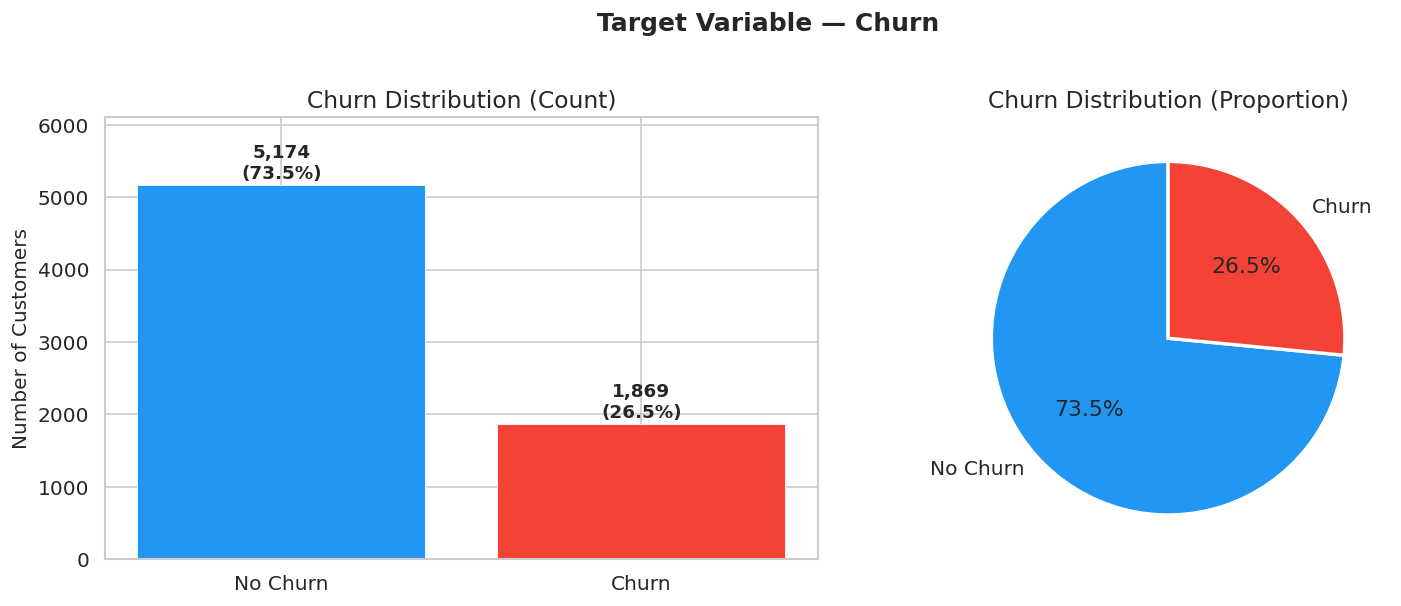


▶  Class imbalance ratio  : 2.77 : 1
▶  Baseline accuracy      : 73.5% (always predict 'No Churn')
▶  Imbalance strategy     : Use class_weight='balanced' or SMOTE during modeling



In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
bars = axes[0].bar(
    ['No Churn', 'Churn'],
    churn_counts.values,
    color=[CHURN_PALETTE[0], CHURN_PALETTE[1]],
    edgecolor='white', linewidth=0.5
)
for bar, cnt, pct in zip(bars, churn_counts.values, churn_pct.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30,
        f'{cnt:,}\n({pct:.1f}%)',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )
axes[0].set_title('Churn Distribution (Count)')
axes[0].set_ylabel('Number of Customers')
axes[0].set_ylim(0, churn_counts.max() * 1.18)

# Pie chart
axes[1].pie(
    churn_counts.values,
    labels=['No Churn', 'Churn'],
    autopct='%1.1f%%',
    colors=[CHURN_PALETTE[0], CHURN_PALETTE[1]],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Churn Distribution (Proportion)')

plt.suptitle('Target Variable — Churn', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"""
▶  Class imbalance ratio  : {churn_counts[0] / churn_counts[1]:.2f} : 1
▶  Baseline accuracy      : {churn_counts[0]/churn_counts.sum()*100:.1f}% (always predict 'No Churn')
▶  Imbalance strategy     : Use class_weight='balanced' or SMOTE during modeling
""")

## 4. Univariate Analysis — Numerical Features

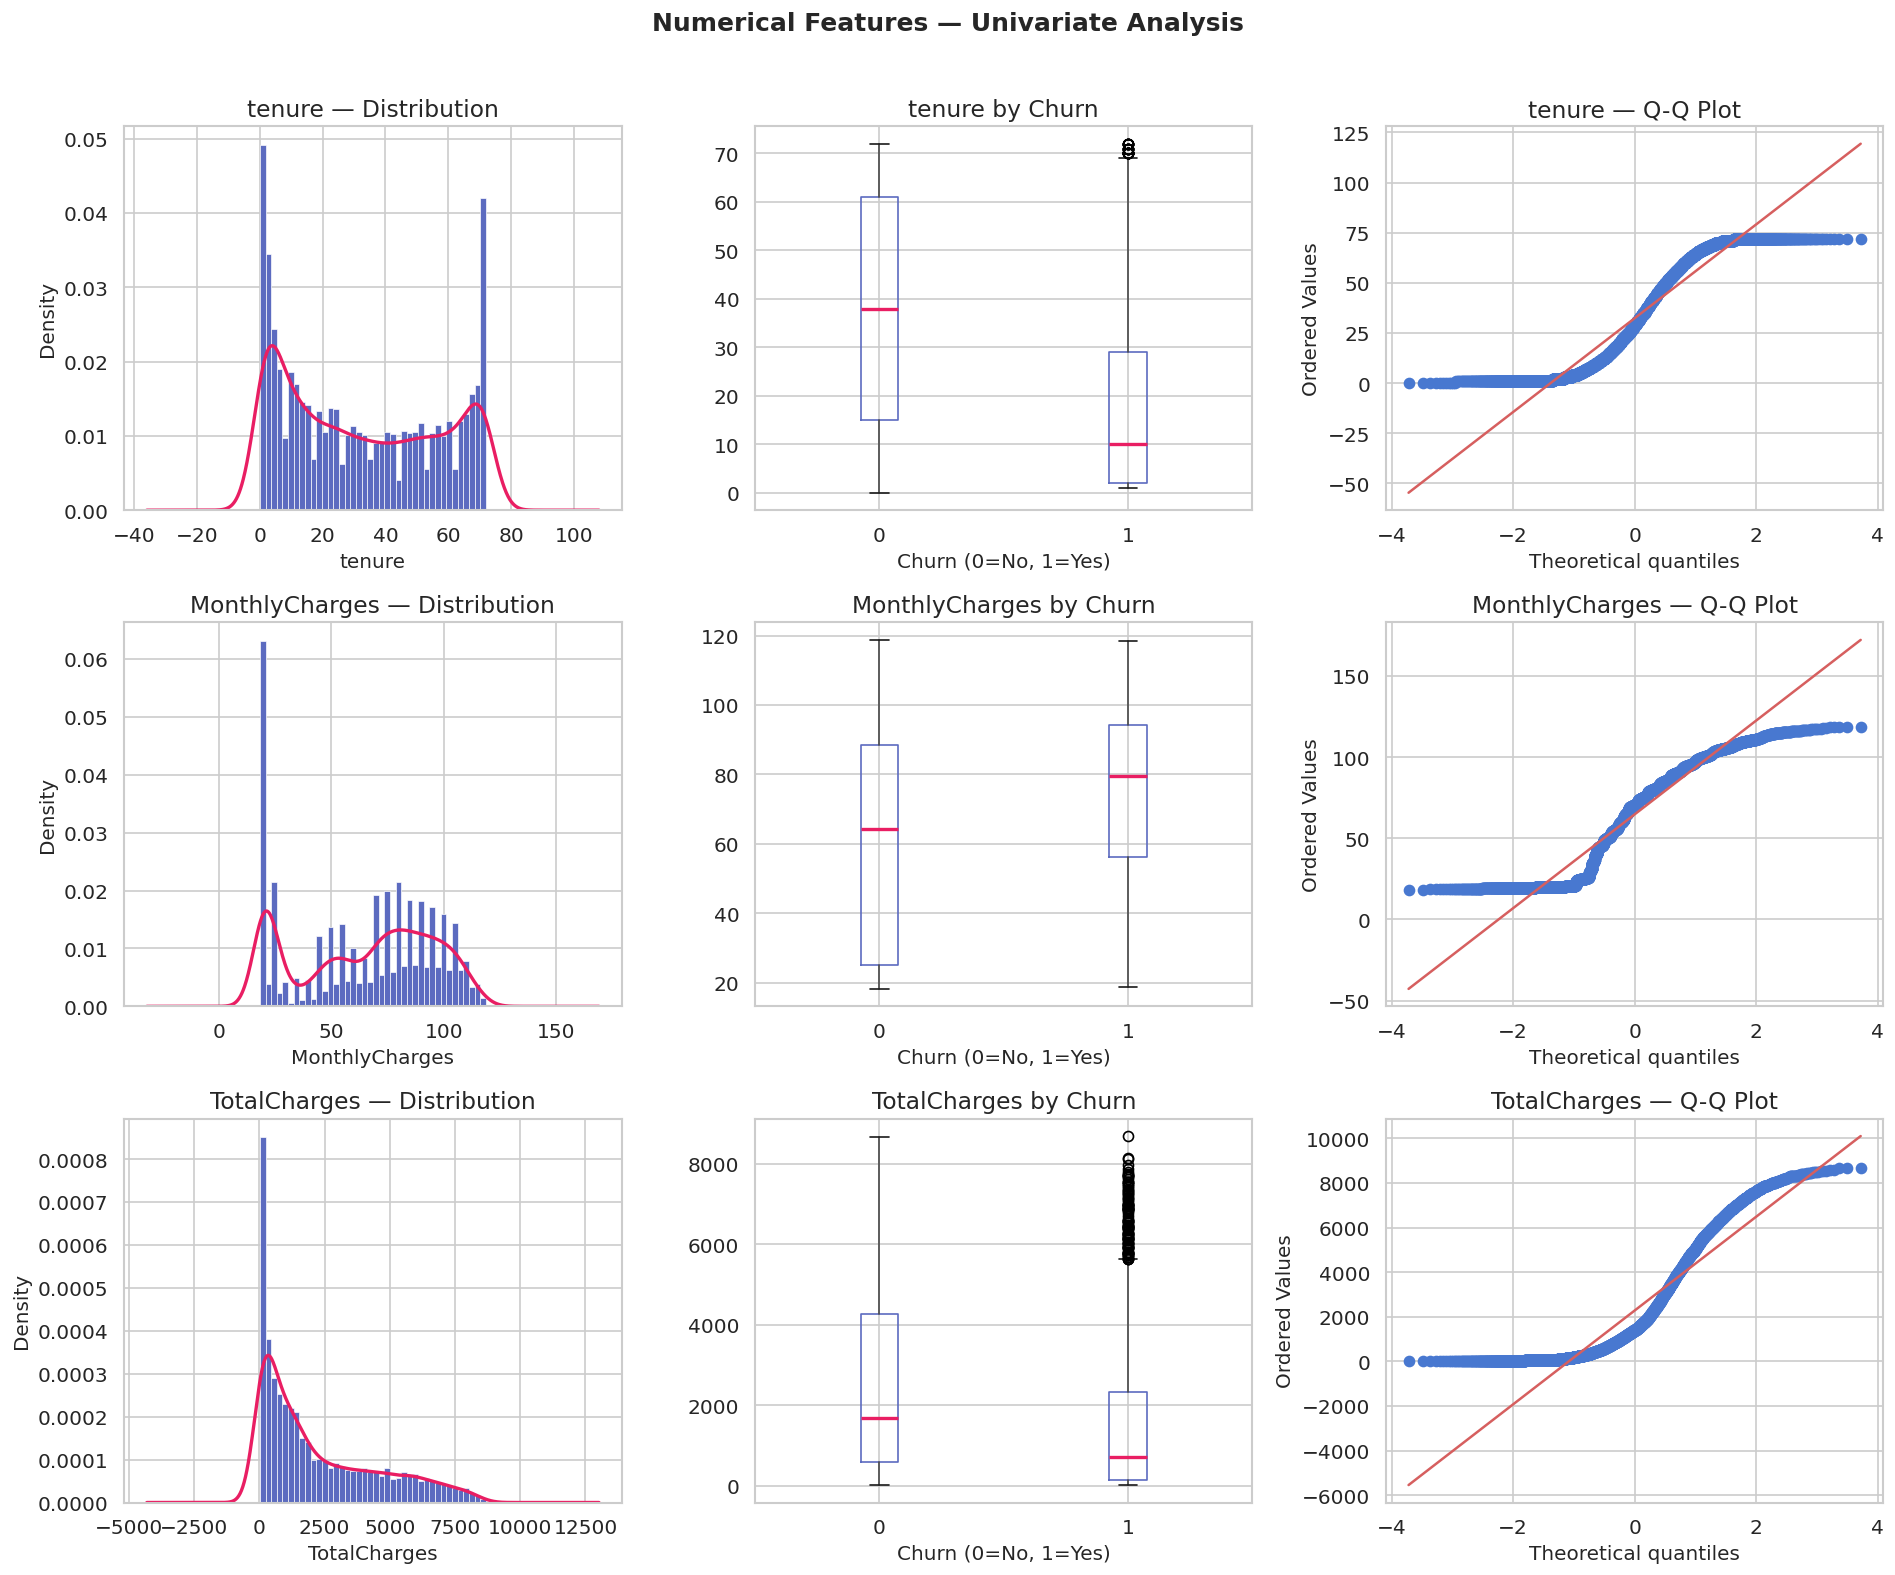


── Descriptive Stats by Churn ──


tenure                                            MonthlyCharges  \
        count   mean    std  min   25%   50%   75%   max          count   
Churn                                                                     
0      5174.0  37.57  24.11  0.0  15.0  38.0  61.0  72.0         5174.0   
1      1869.0  17.98  19.53  1.0   2.0  10.0  29.0  72.0         1869.0   

                     ...                      TotalCharges                    \
        mean    std  ...    50%   75%     max        count     mean      std   
Churn                ...                                                       
0      61.27  31.09  ...  64.43  88.4  118.75       5174.0  2552.88  2327.59   
1      74.44  24.67  ...  79.65  94.2  118.35       1869.0  1531.80  1890.82   

                                                 
         min     25%      50%      75%      max  
Churn                                            
0      18.80  579.58  1679.52  4262.85  8672.45  
1      18.85  134.50   703.55  2331.30  8684.80  

[2 rows x 24 columns]

In [22]:
NUM_COLS = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(3, 3, figsize=(16, 13))

for i, col in enumerate(NUM_COLS):
    data = df[col].dropna()

    # Histogram + KDE
    axes[i, 0].hist(data, bins=40, color='#5C6BC0', edgecolor='white', linewidth=0.4, density=True)
    data.plot.kde(ax=axes[i, 0], color='#E91E63', linewidth=2)
    axes[i, 0].set_title(f'{col} — Distribution')
    axes[i, 0].set_xlabel(col)

    # Box plot by Churn
    df.boxplot(column=col, by='Churn', ax=axes[i, 1],
               boxprops=dict(color='#5C6BC0'),
               medianprops=dict(color='#E91E63', linewidth=2))
    axes[i, 1].set_title(f'{col} by Churn')
    axes[i, 1].set_xlabel('Churn (0=No, 1=Yes)')

    # QQ-plot
    stats.probplot(data, dist='norm', plot=axes[i, 2])
    axes[i, 2].set_title(f'{col} — Q-Q Plot')

plt.suptitle('Numerical Features — Univariate Analysis', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Descriptive stats split by Churn
print('\n── Descriptive Stats by Churn ──')
df.groupby('Churn')[NUM_COLS].describe().round(2)

In [23]:
# ── Outlier detection — IQR method ──────────────────────────────────────────
print('── Outlier Analysis (IQR method) ──')
for col in NUM_COLS:
    data = df[col].dropna()
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((data < lower) | (data > upper)).sum()
    print(f'  {col:<20} lower={lower:.1f}  upper={upper:.1f}  outliers={n_out} ({n_out/len(data)*100:.2f}%)')

── Outlier Analysis (IQR method) ──
  tenure               lower=-60.0  upper=124.0  outliers=0 (0.00%)
  MonthlyCharges       lower=-46.0  upper=171.4  outliers=0 (0.00%)
  TotalCharges         lower=-4674.3  upper=8863.2  outliers=0 (0.00%)


## 5. Univariate Analysis — Categorical Features

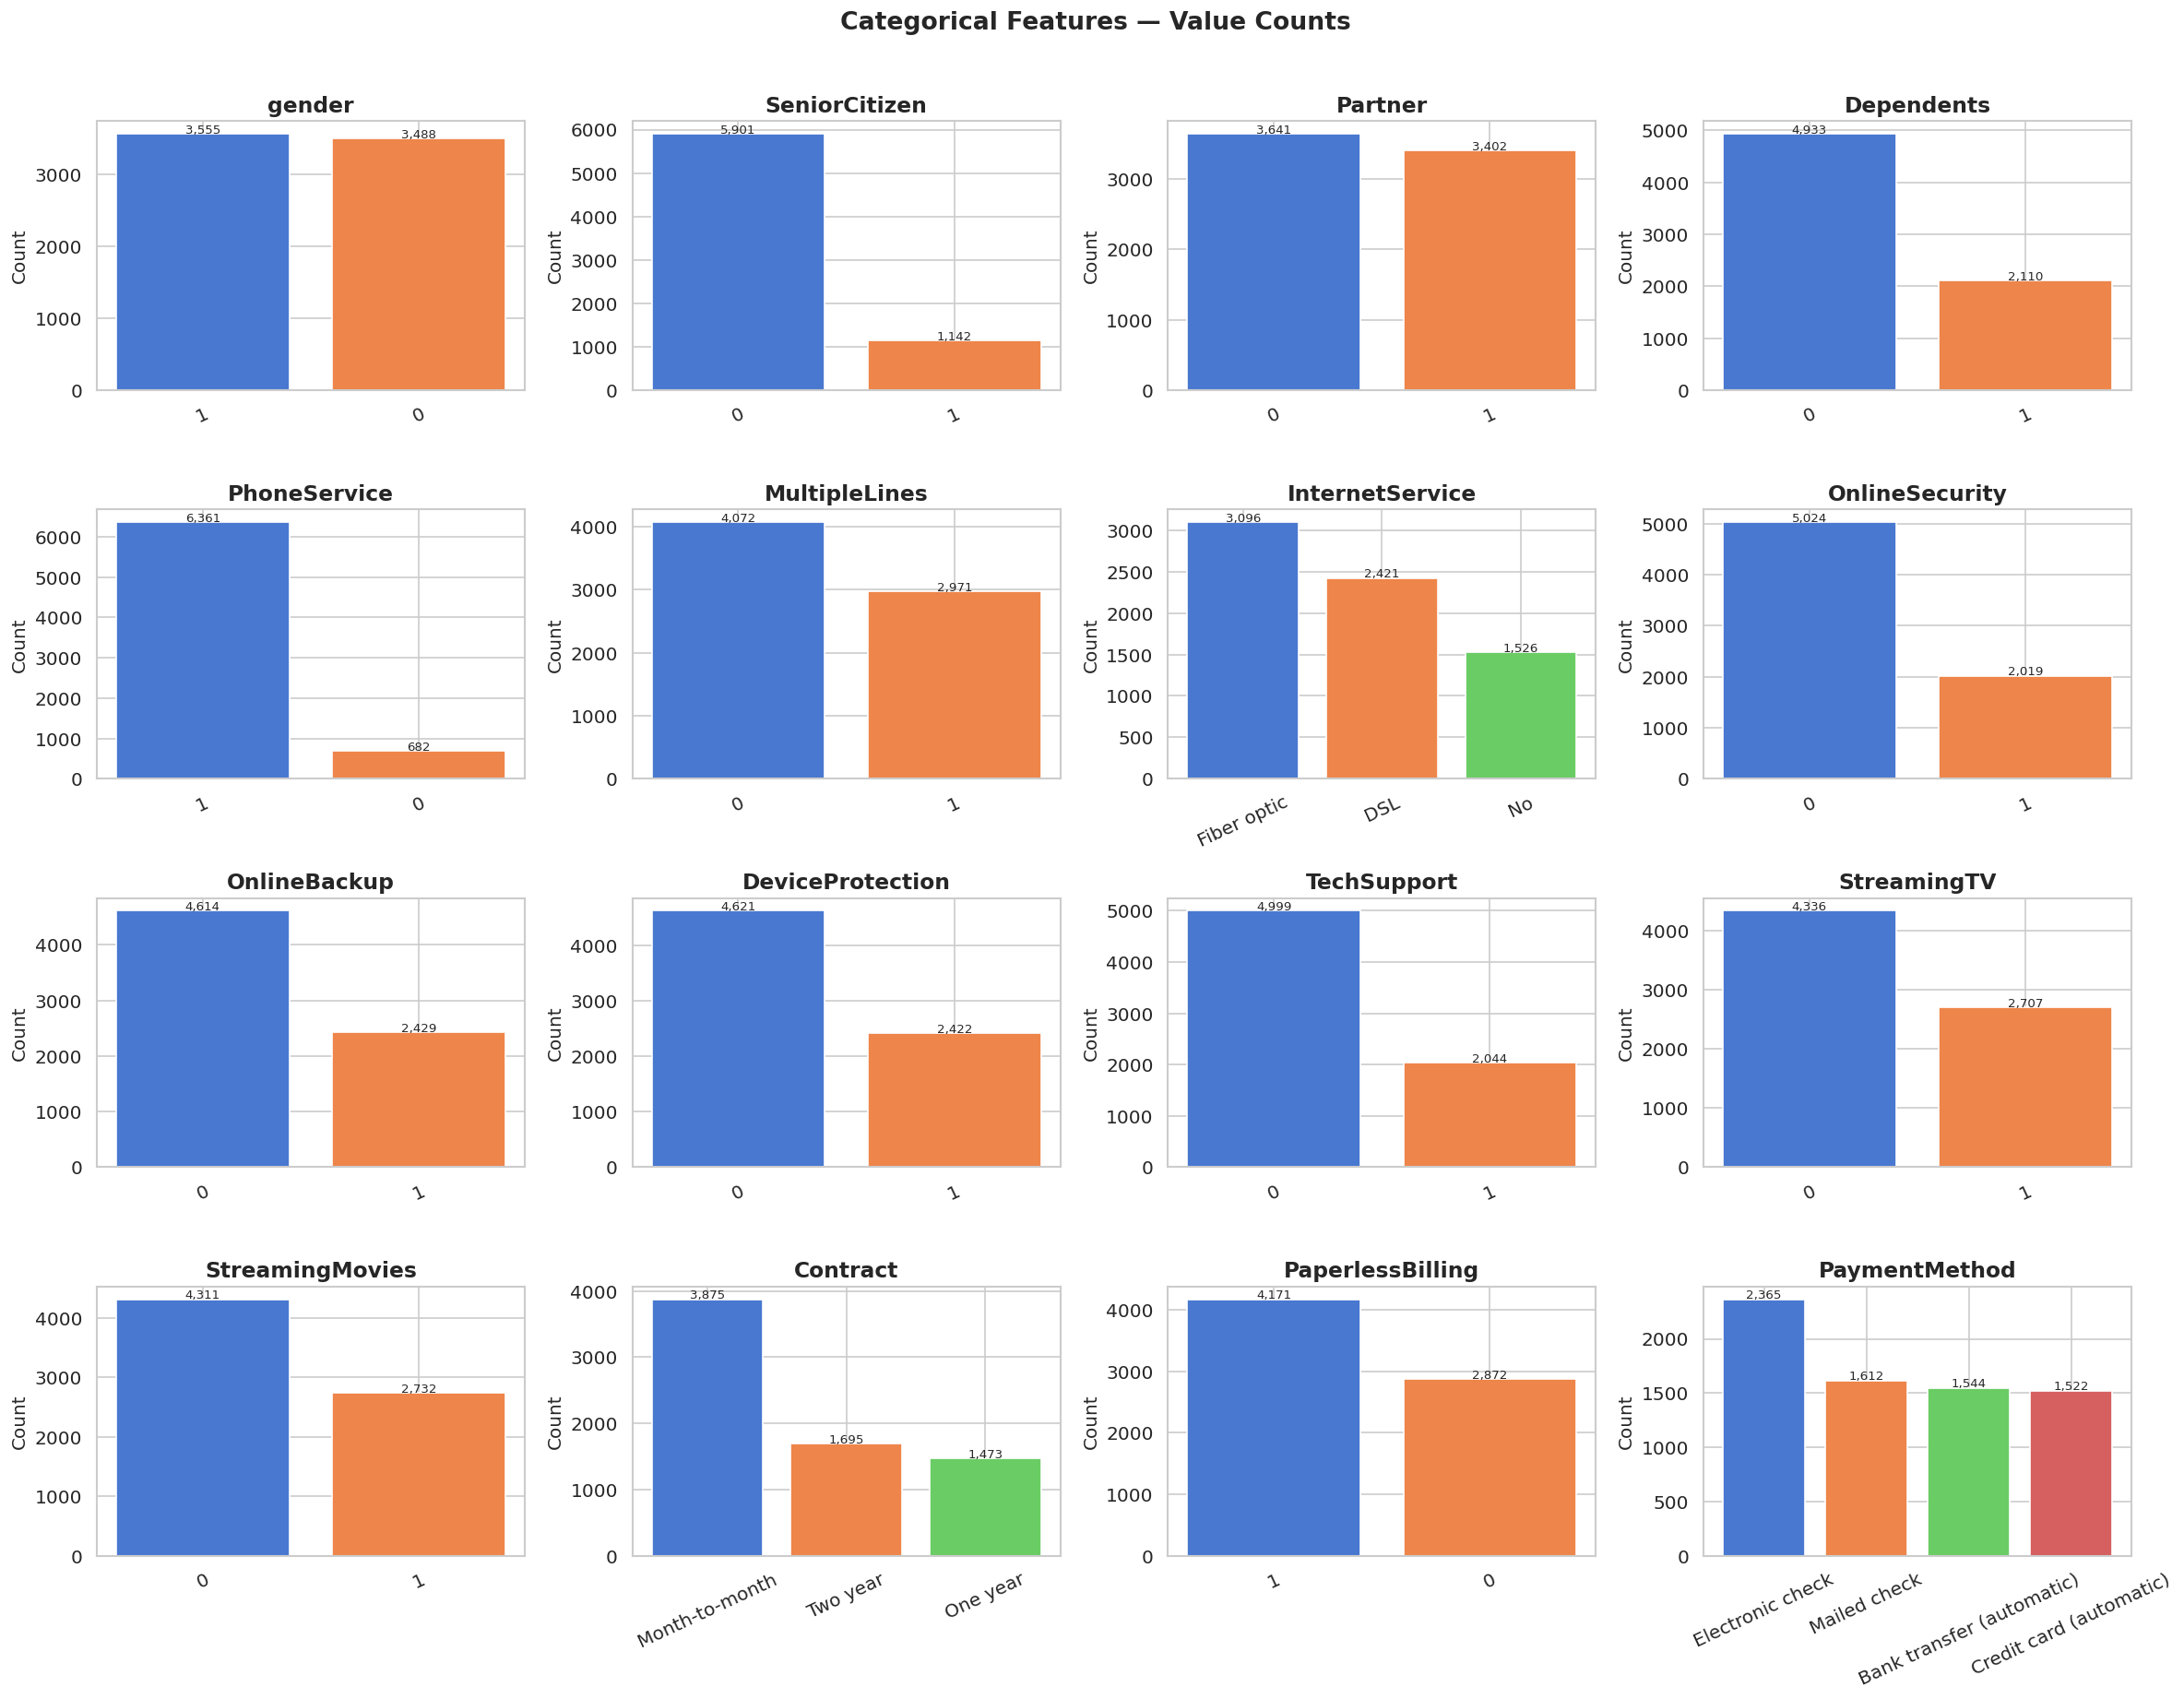

In [35]:
CAT_COLS = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

# Determine grid size
n_cols = 4
n_rows = -(-len(CAT_COLS) // n_cols)   # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3.8))
axes = axes.flatten()

for i, col in enumerate(CAT_COLS):
    counts = df[col].value_counts()
    colors = sns.color_palette('muted', len(counts))
    axes[i].bar(counts.index.astype(str), counts.values, color=colors, edgecolor='white')
    axes[i].set_title(col, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=25)
    axes[i].set_ylabel('Count')
    for j, v in enumerate(counts.values):
        axes[i].text(j, v + 10, f'{v:,}', ha='center', fontsize=8)

# Remove unused axes
for j in range(len(CAT_COLS), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Categorical Features — Value Counts', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()

plt.savefig('categorical_univariate_analysis.png', dpi=500, bbox_inches='tight')

plt.show()

## 6. Bivariate Analysis — Features vs Churn

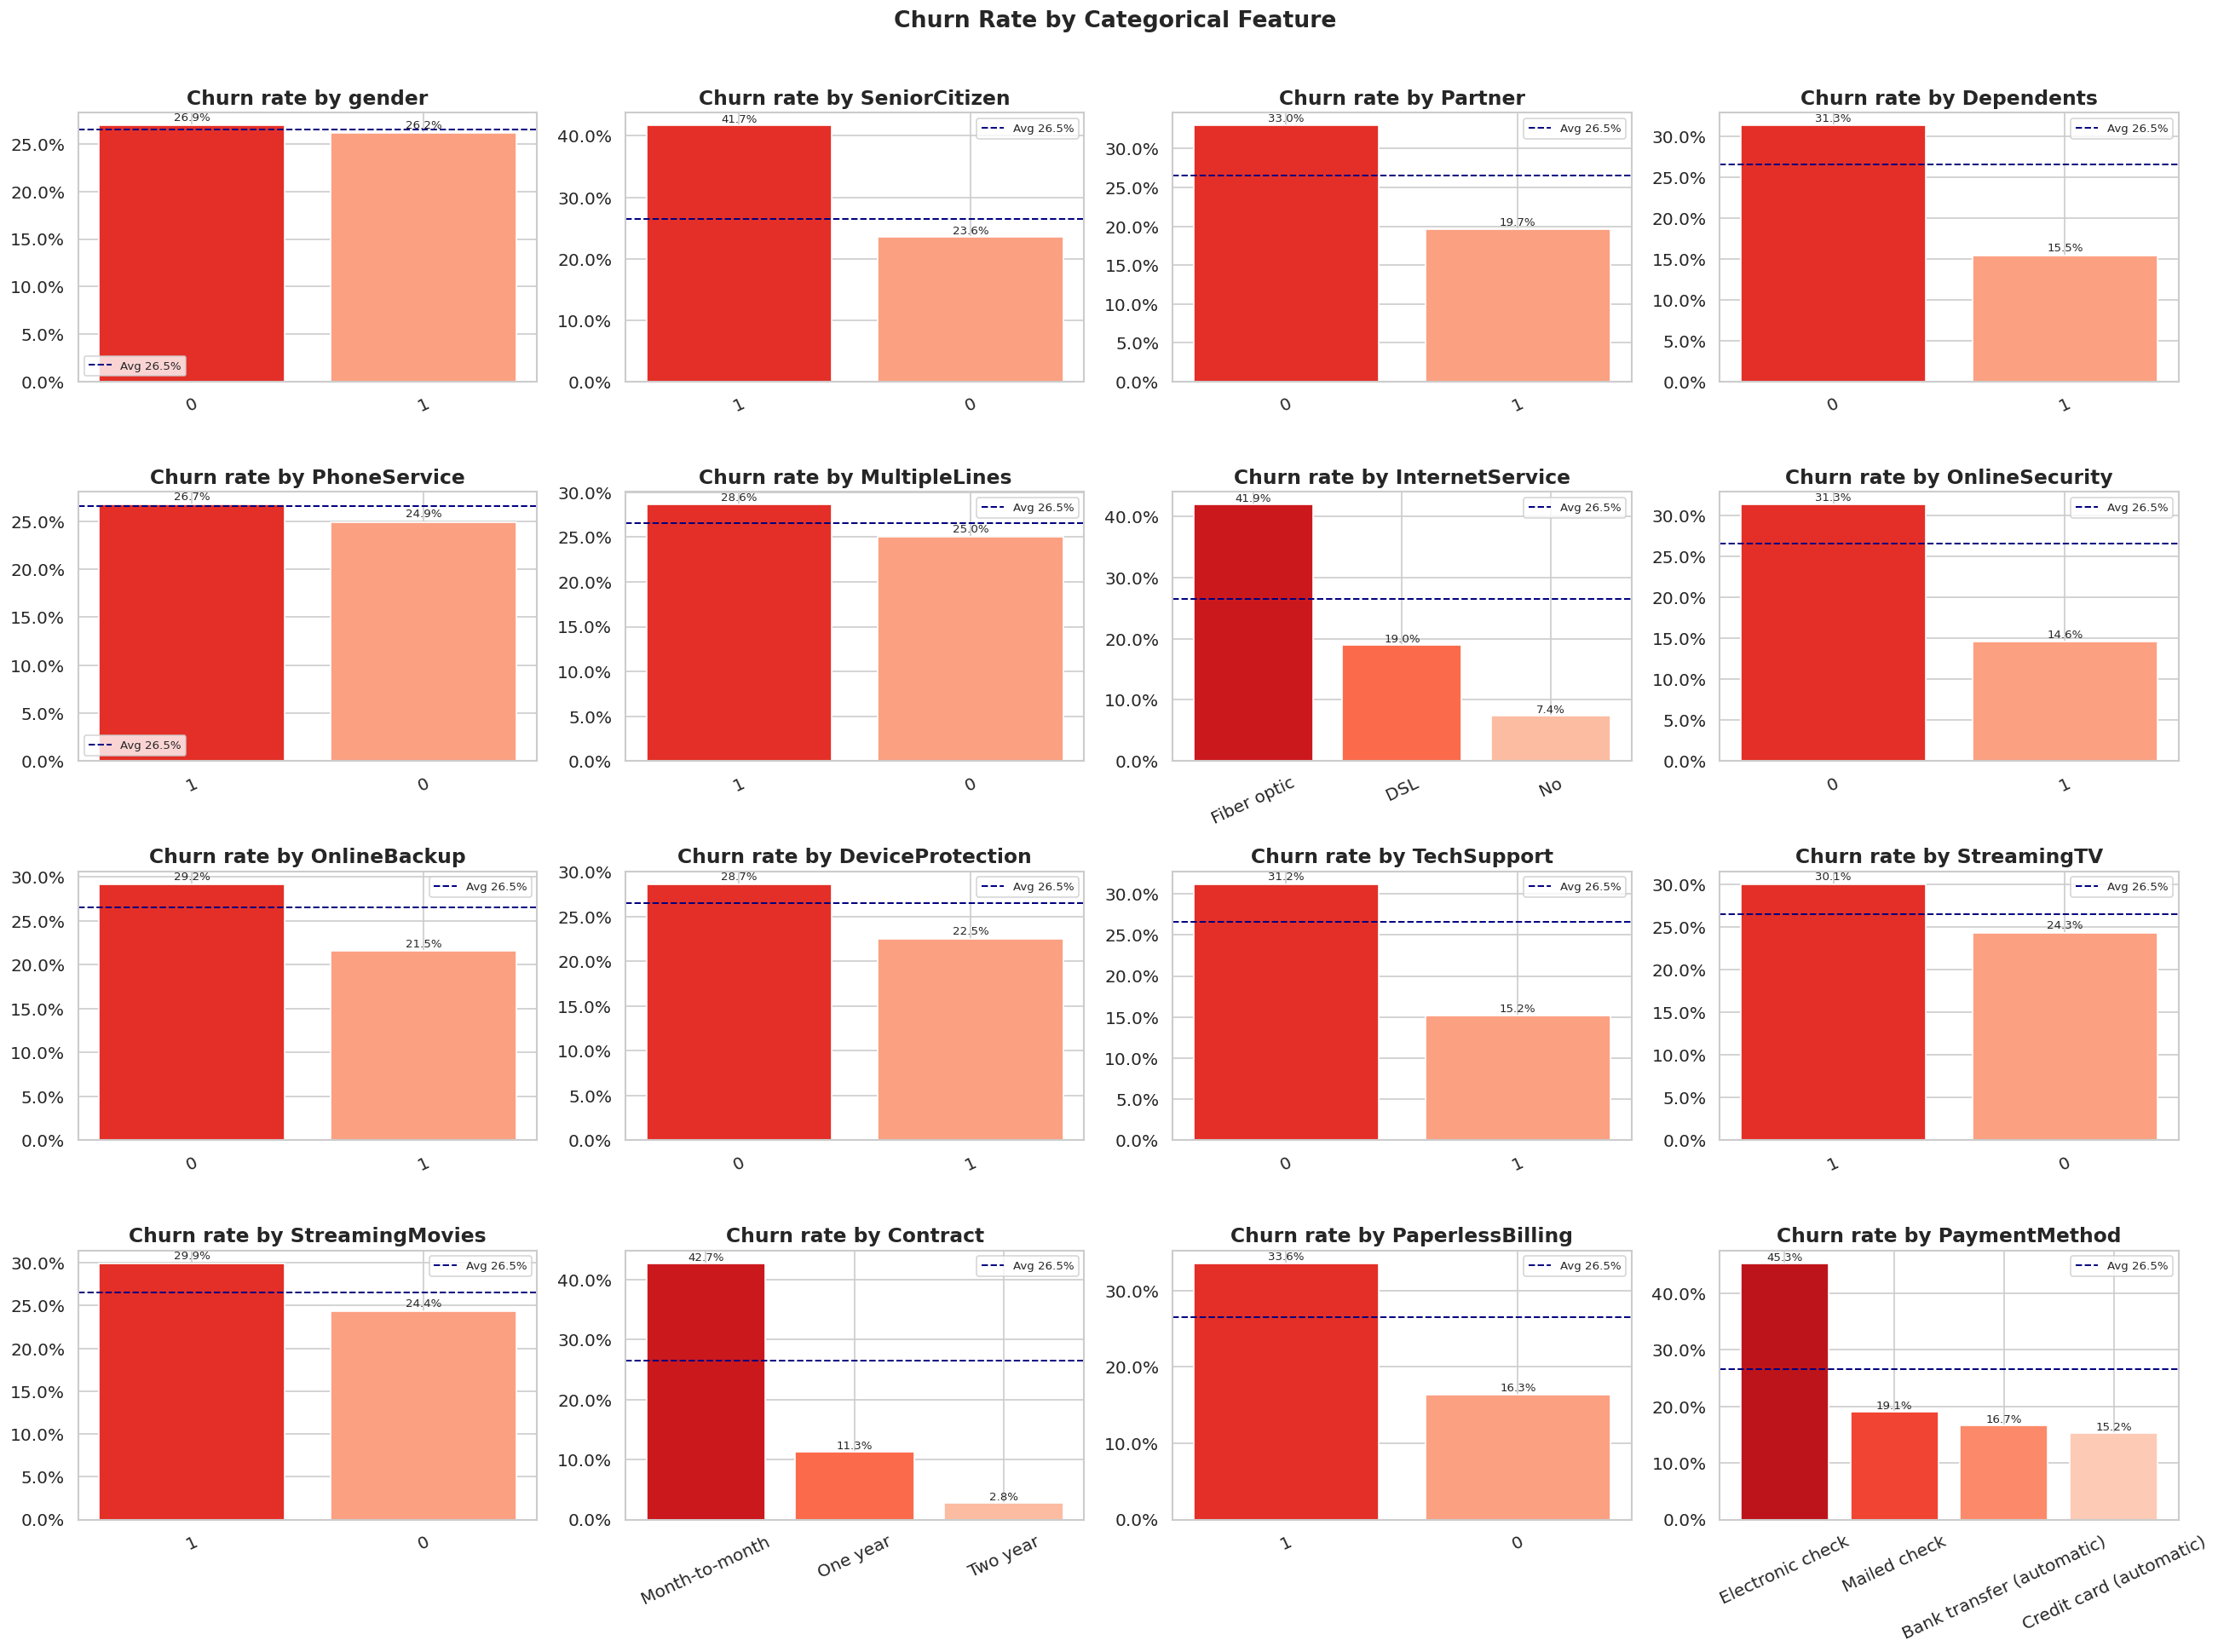

In [37]:
# ── Churn rate per categorical feature ──────────────────────────────────────
n_cols = 4
n_rows = -(-len(CAT_COLS) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(CAT_COLS):
    churn_rate = df.groupby(col)['Churn'].mean().sort_values(ascending=False) * 100
    bars = axes[i].bar(
        churn_rate.index.astype(str),
        churn_rate.values,
        color=sns.color_palette('Reds_r', len(churn_rate)),
        edgecolor='white'
    )
    axes[i].yaxis.set_major_formatter(mtick.PercentFormatter())
    axes[i].set_title(f'Churn rate by {col}', fontweight='bold')
    axes[i].tick_params(axis='x', rotation=25)
    # Add global churn baseline
    global_rate = df['Churn'].mean() * 100
    axes[i].axhline(global_rate, color='navy', linewidth=1.2, linestyle='--', label=f'Avg {global_rate:.1f}%')
    axes[i].legend(fontsize=8)
    for bar, val in zip(bars, churn_rate.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f'{val:.1f}%', ha='center', fontsize=8)

for j in range(len(CAT_COLS), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Churn Rate by Categorical Feature', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

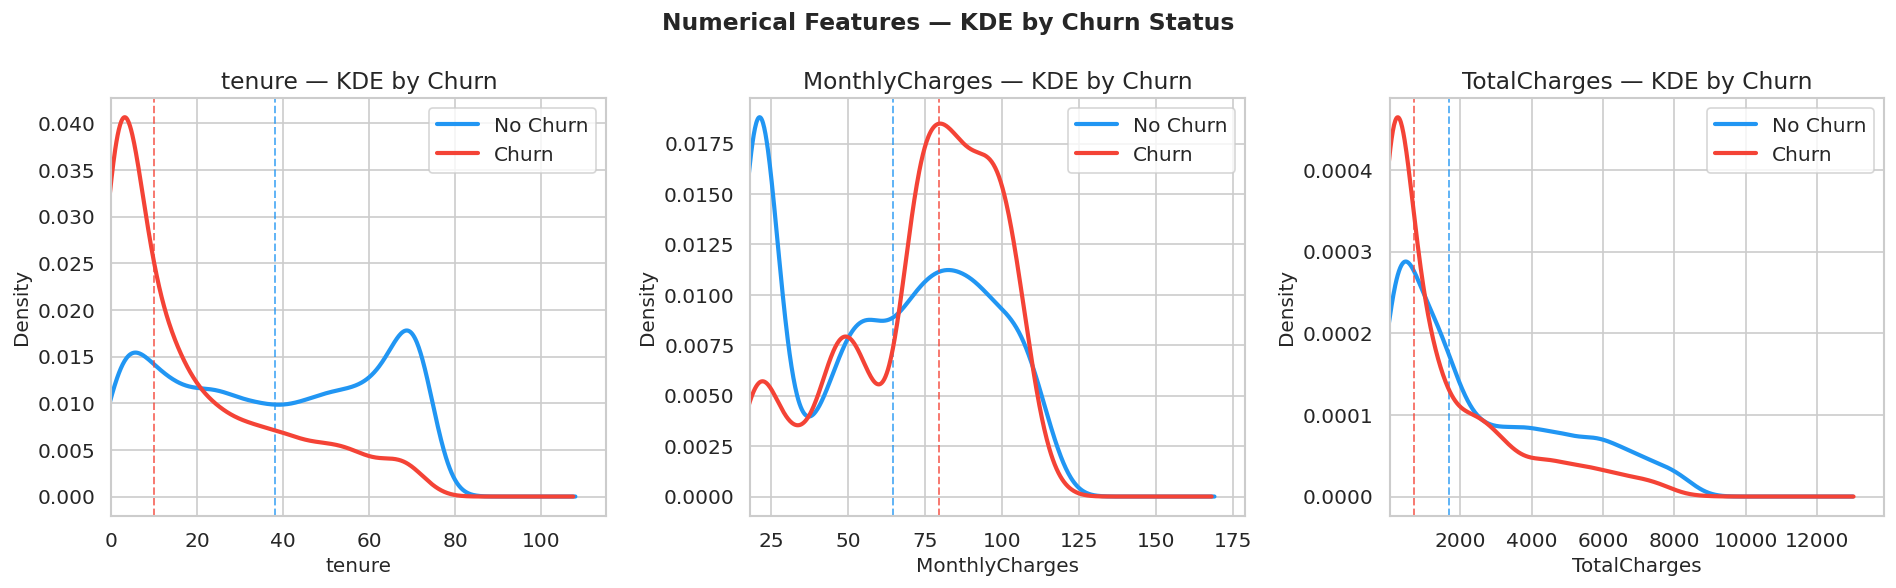

In [40]:
# ── Numerical features vs Churn — KDE overlay ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(NUM_COLS):
    for churn_val, label in CHURN_LABELS.items():
        subset = df[df['Churn'] == churn_val][col].dropna()
        subset.plot.kde(ax=axes[i], color=CHURN_PALETTE[churn_val],
                        linewidth=2.5, label=label)
        axes[i].axvline(subset.median(), color=CHURN_PALETTE[churn_val],
                        linestyle='--', linewidth=1.2, alpha=0.7)
    axes[i].set_title(f'{col} — KDE by Churn')
    axes[i].set_xlabel(col)
    axes[i].legend()
    axes[i].set_xlim(left=df[col].min())

plt.suptitle('Numerical Features — KDE by Churn Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('kde_analysis.png', dpi=500, bbox_inches='tight')

plt.show()

In [27]:
# ── Mann-Whitney U test — are distributions significantly different? ──────────
print('── Mann-Whitney U Test (Churn vs No-Churn) ──')
print(f'{"Feature":<20} {"Stat":>10} {"p-value":>12} {"Significant":>12}')
print('-' * 56)
for col in NUM_COLS:
    g0 = df[df['Churn'] == 0][col].dropna()
    g1 = df[df['Churn'] == 1][col].dropna()
    stat, p = stats.mannwhitneyu(g0, g1, alternative='two-sided')
    sig = '✅ Yes' if p < 0.05 else '❌ No'
    print(f'{col:<20} {stat:>10.0f} {p:>12.4e} {sig:>12}')

── Mann-Whitney U Test (Churn vs No-Churn) ──
Feature                    Stat      p-value  Significant
--------------------------------------------------------
tenure                  7154668  2.4196e-208        ✅ Yes
MonthlyCharges          3667080   3.3116e-54        ✅ Yes
TotalCharges            6302281   1.8396e-84        ✅ Yes


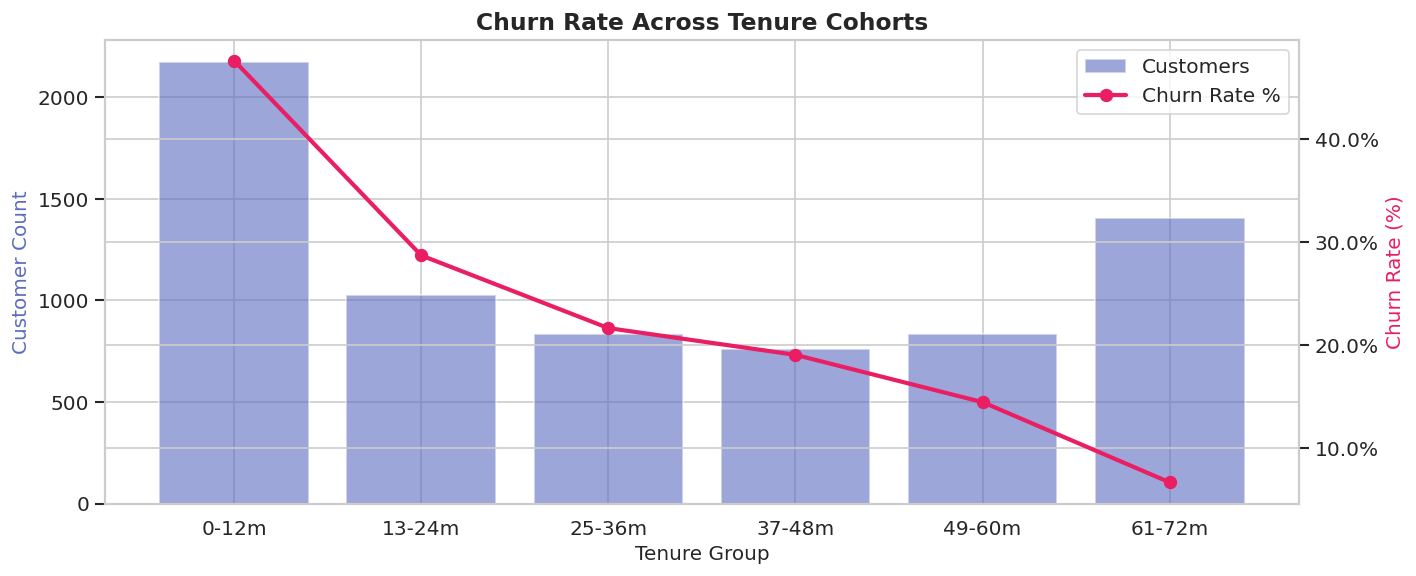

tenure_group  customers  churned  churn_rate
       0-12m       2175     1037    0.476782
      13-24m       1024      294    0.287109
      25-36m        832      180    0.216346
      37-48m        762      145    0.190289
      49-60m        832      120    0.144231
      61-72m       1407       93    0.066098


In [28]:
# ── Tenure cohort analysis ────────────────────────────────────────────────────
df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 36, 48, 60, 72],
    labels=['0-12m', '13-24m', '25-36m', '37-48m', '49-60m', '61-72m']
)

cohort = df.groupby('tenure_group', observed=True).agg(
    customers=('Churn', 'count'),
    churned=('Churn', 'sum'),
    churn_rate=('Churn', 'mean')
).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.bar(cohort['tenure_group'].astype(str), cohort['customers'], color='#5C6BC0', alpha=0.6, label='Customers')
ax2.plot(cohort['tenure_group'].astype(str), cohort['churn_rate'] * 100,
         color='#E91E63', linewidth=2.5, marker='o', markersize=7, label='Churn Rate %')

ax1.set_ylabel('Customer Count', color='#5C6BC0')
ax2.set_ylabel('Churn Rate (%)', color='#E91E63')
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
ax1.set_xlabel('Tenure Group')
ax1.set_title('Churn Rate Across Tenure Cohorts', fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
plt.tight_layout()
plt.show()

print(cohort.to_string(index=False))

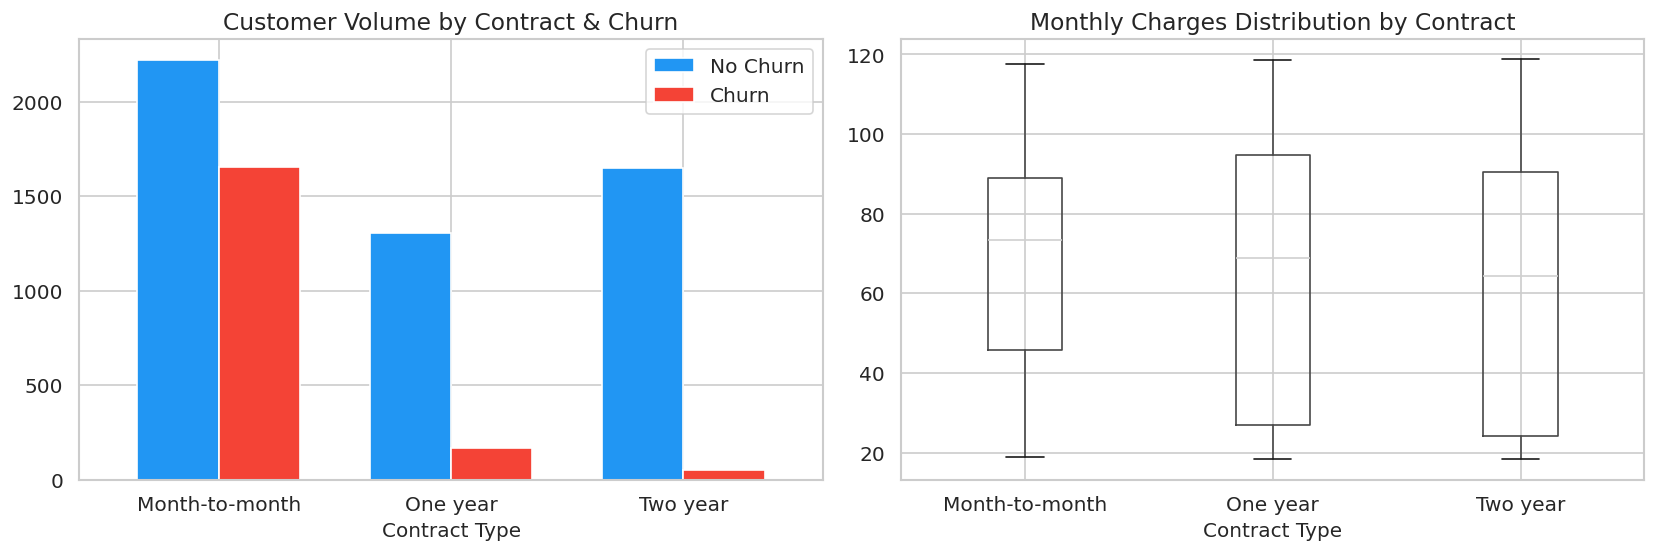

In [29]:
# ── Contract type deep-dive ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grouped bar — customer mix
contract_churn = df.groupby(['Contract', 'Churn']).size().unstack().fillna(0)
contract_churn.plot(kind='bar', ax=axes[0],
                    color=[CHURN_PALETTE[0], CHURN_PALETTE[1]],
                    edgecolor='white', width=0.7)
axes[0].set_title('Customer Volume by Contract & Churn')
axes[0].set_xlabel('Contract Type')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(['No Churn', 'Churn'])

# Monthly charges distribution by contract type
contract_order = df.groupby('Contract')['MonthlyCharges'].median().sort_values(ascending=False).index
df.boxplot(
    column='MonthlyCharges', by='Contract',
    ax=axes[1], vert=True
)
axes[1].set_title('Monthly Charges Distribution by Contract')
axes[1].set_xlabel('Contract Type')

plt.suptitle('')
plt.tight_layout()
plt.show()

## 7. Correlation & Multicollinearity

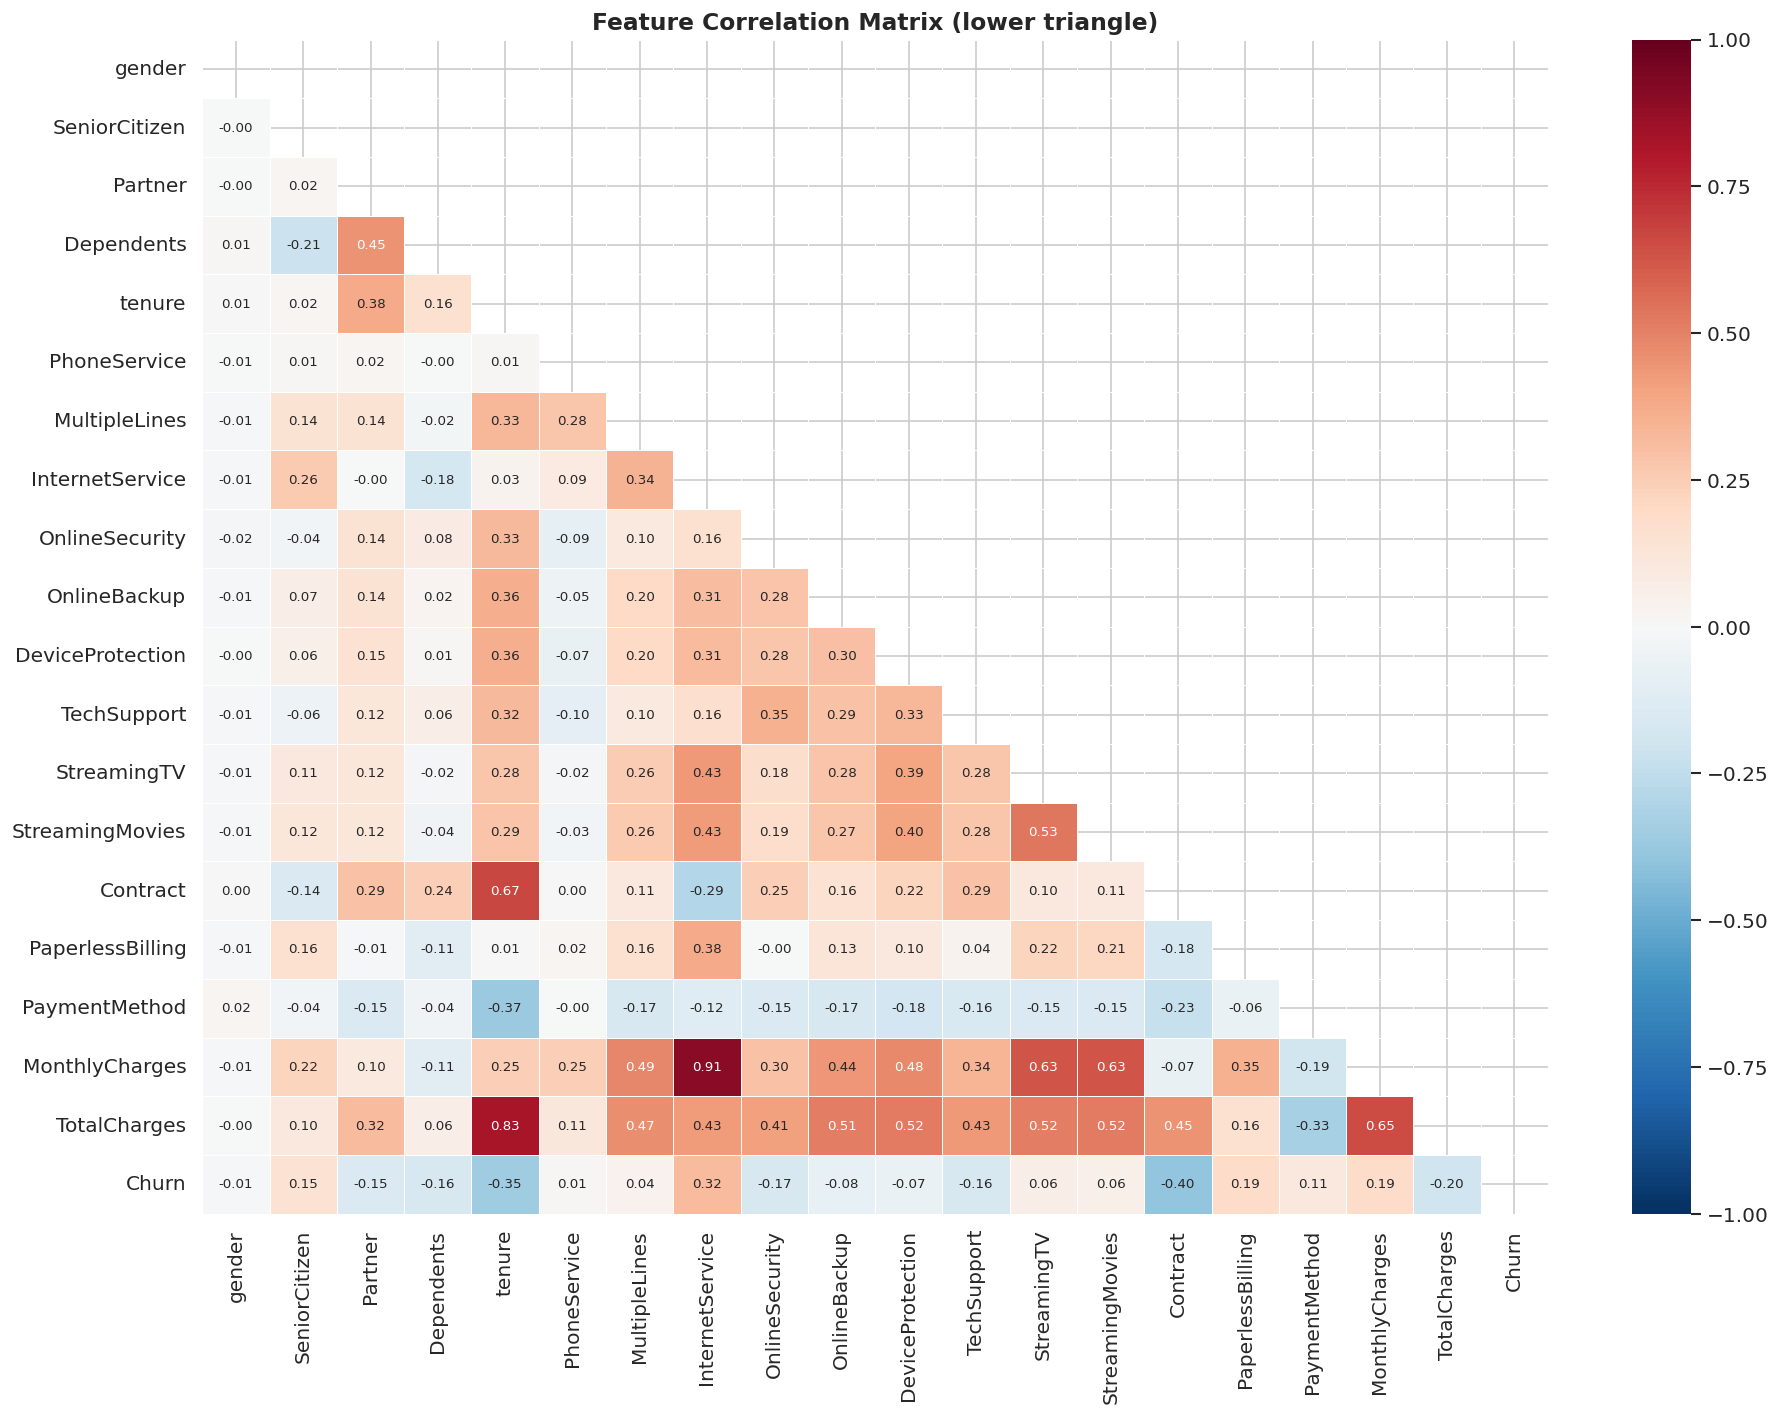

In [30]:
# ── Encode categoricals for correlation analysis ─────────────────────────────
df_encoded = df.copy().drop(columns=['customerID', 'tenure_group'])

binary_map = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0,
              'No phone service': 0, 'No internet service': 0}
for col in df_encoded.select_dtypes('object').columns:
    df_encoded[col] = df_encoded[col].replace(binary_map)
    if df_encoded[col].dtype == object:
        df_encoded[col] = pd.Categorical(df_encoded[col]).codes

corr_matrix = df_encoded.corr(numeric_only=True)

# Full heatmap
fig, ax = plt.subplots(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', vmin=-1, vmax=1,
    linewidths=0.5, annot_kws={'size': 8},
    ax=ax
)
ax.set_title('Feature Correlation Matrix (lower triangle)', fontweight='bold')
plt.tight_layout()
plt.show()

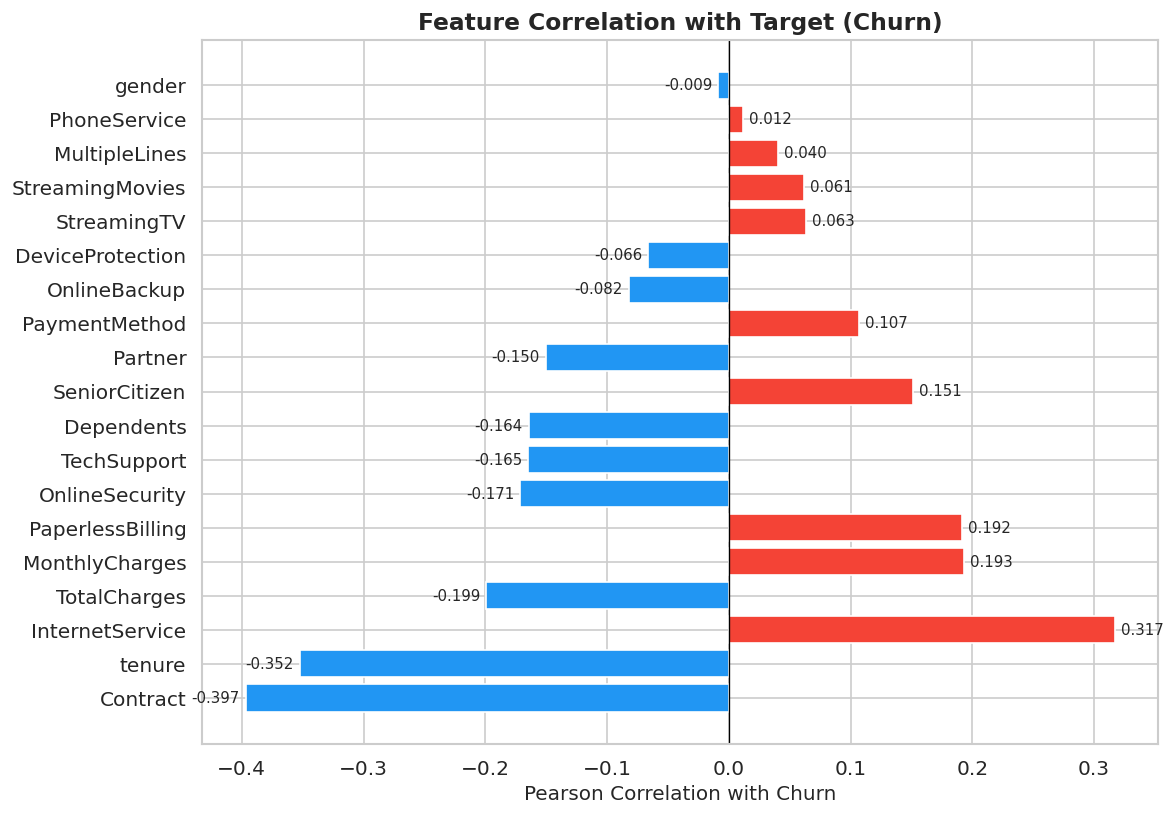


Top 5 positive correlators (churn risk ↑):
InternetService     0.316846
MonthlyCharges      0.193356
PaperlessBilling    0.191825
SeniorCitizen       0.150889
PaymentMethod       0.107062
Name: Churn, dtype: float64

Top 5 negative correlators (churn risk ↓):
Contract         -0.396713
tenure           -0.352229
TotalCharges     -0.199037
OnlineSecurity   -0.171226
TechSupport      -0.164674
Name: Churn, dtype: float64


In [31]:
# ── Correlation with Churn (top drivers) ─────────────────────────────────────
churn_corr = corr_matrix['Churn'].drop('Churn').sort_values(key=abs, ascending=False)

colors = ['#F44336' if v > 0 else '#2196F3' for v in churn_corr.values]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(churn_corr.index, churn_corr.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson Correlation with Churn')
ax.set_title('Feature Correlation with Target (Churn)', fontweight='bold')
for bar, val in zip(bars, churn_corr.values):
    xpos = bar.get_width() + (0.005 if val >= 0 else -0.005)
    ax.text(xpos, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.show()

print('\nTop 5 positive correlators (churn risk ↑):')
print(churn_corr[churn_corr > 0].head())
print('\nTop 5 negative correlators (churn risk ↓):')
print(churn_corr[churn_corr < 0].head())

In [32]:
# ── Multicollinearity check — Variance Inflation Factor (VIF) ────────────────
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = df_encoded.drop(columns=['Churn']).dropna()
vif_results = pd.DataFrame({
    'Feature': vif_data.columns,
    'VIF': [variance_inflation_factor(vif_data.values, i) for i in range(vif_data.shape[1])]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

# Color-coded display
def vif_flag(v):
    if v > 10: return '🔴 HIGH'
    if v > 5:  return '🟡 MODERATE'
    return '🟢 OK'

vif_results['Status'] = vif_results['VIF'].apply(vif_flag)
print('── Variance Inflation Factors ──')
print(vif_results.to_string(index=False))

── Variance Inflation Factors ──
         Feature         VIF     Status
  MonthlyCharges 4867.985897     🔴 HIGH
 InternetService 1257.691704     🔴 HIGH
    PhoneService  353.104688     🔴 HIGH
 StreamingMovies   39.368237     🔴 HIGH
     StreamingTV   39.054382     🔴 HIGH
    TotalCharges   14.749708     🔴 HIGH
          tenure   14.266316     🔴 HIGH
   MultipleLines   12.515503     🔴 HIGH
DeviceProtection   10.510131     🔴 HIGH
    OnlineBackup   10.293000     🔴 HIGH
     TechSupport    8.950312 🟡 MODERATE
  OnlineSecurity    8.696050 🟡 MODERATE
        Contract    4.065311       🟢 OK
   PaymentMethod    3.007146       🟢 OK
PaperlessBilling    2.877861       🟢 OK
         Partner    2.820108       🟢 OK
      Dependents    1.960888       🟢 OK
          gender    1.953349       🟢 OK
   SeniorCitizen    1.368466       🟢 OK


## 8. Key Findings & EDA Summary

In [33]:
# ── Print structured EDA summary ─────────────────────────────────────────────
total      = len(df)
churn_rate = df['Churn'].mean() * 100
avg_tenure = df.groupby('Churn')['tenure'].mean()
avg_mc     = df.groupby('Churn')['MonthlyCharges'].mean()

print(f"""
╔══════════════════════════════════════════════════════════════════╗
║                   EDA KEY FINDINGS SUMMARY                       ║
╚══════════════════════════════════════════════════════════════════╝

📦 DATASET
   • Total customers   : {total:,}
   • Features          : 21 (1 target, 19 predictors, 1 ID)
   • Missing values    : TotalCharges has {df['TotalCharges'].isnull().sum()} nulls (new customers with no charges)

🎯 TARGET (Churn)
   • Overall churn rate  : {churn_rate:.1f}%   → Class imbalance present
   • Avg tenure (churned): {avg_tenure[1]:.1f} months vs {avg_tenure[0]:.1f} months (stayed)
   • Avg monthly charge (churned): ${avg_mc[1]:.2f} vs ${avg_mc[0]:.2f} (stayed)

🔑 STRONGEST CHURN PREDICTORS
   1. Contract type        — Month-to-month customers churn at >3x the rate of 2-year contracts
   2. Tenure               — Most churn occurs in first 12 months (early-stage churn)
   3. Internet Service     — Fiber optic users churn more than DSL users
   4. Online Security      — Customers without security add-ons churn more
   5. TechSupport          — Similar pattern to Online Security
   6. PaymentMethod        — Electronic check payers have highest churn rate
   7. MonthlyCharges       — Higher charges correlate with higher churn

⚠️  DATA QUALITY NOTES
   • TotalCharges needs imputation (11 rows, likely tenure=0 customers)
   • 'No internet service' / 'No phone service' should be collapsed to 'No'
   • SeniorCitizen is already encoded as 0/1 (unlike other binary cols)

📌 MODELING RECOMMENDATIONS
   • Handle class imbalance: class_weight='balanced' or SMOTE
   • Focus on RECALL for churn class (catching churners > false alarms)
   • Feature engineering: tenure groups, charge-per-month ratio, service count
   • Consider tree-based models — they handle mixed-type features well
""")


╔══════════════════════════════════════════════════════════════════╗
║                   EDA KEY FINDINGS SUMMARY                       ║
╚══════════════════════════════════════════════════════════════════╝

📦 DATASET
   • Total customers   : 7,043
   • Features          : 21 (1 target, 19 predictors, 1 ID)
   • Missing values    : TotalCharges has 0 nulls (new customers with no charges)

🎯 TARGET (Churn)
   • Overall churn rate  : 26.5%   → Class imbalance present
   • Avg tenure (churned): 18.0 months vs 37.6 months (stayed)
   • Avg monthly charge (churned): $74.44 vs $61.27 (stayed)

🔑 STRONGEST CHURN PREDICTORS
   1. Contract type        — Month-to-month customers churn at >3x the rate of 2-year contracts
   2. Tenure               — Most churn occurs in first 12 months (early-stage churn)
   3. Internet Service     — Fiber optic users churn more than DSL users
   4. Online Security      — Customers without security add-ons churn more
   5. TechSupport          — Similar pattern 

In [34]:
# ── Cleanup temp column ──────────────────────────────────────────────────────
df.drop(columns=['tenure_group'], inplace=True, errors='ignore')
print('EDA complete. Proceed to 02_feature_engineering.ipynb')

EDA complete. Proceed to 02_feature_engineering.ipynb
